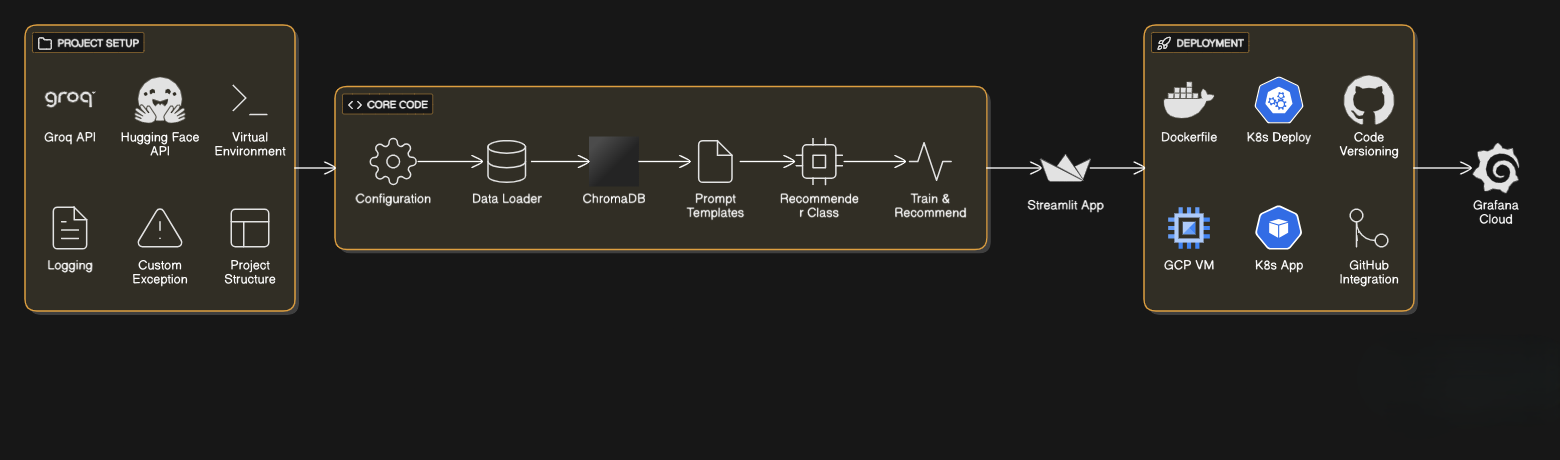

In [16]:
from IPython.display import Image, display; display(Image('/content/data/AI+Anime+Recommender+Workflow.png'))

In [13]:
pip install --q --upgrade sentence-transformers transformers pillow huggingface_hub

# 🌸 AniBaba — AI Anime Recommender
> **RAG-powered anime recommendation system**  
> Groq LLM (Qwen3-32B) · ChromaDB · HuggingFace Embeddings · LangChain Tool-Calling

---

## 📁 Project Structure
```
AniBaba/
├── config/
│   ├── __init__.py
│   └── config.py            # API keys & model name
├── data/
│   ├── anime_with_synopsis.csv   # ← upload this
│   └── anime_updated.csv         # generated by Stage 2
├── src/
│   ├── __init__.py
│   ├── data_loader.py       # Stage 2: ingestion
│   ├── vector_store.py      # Stage 3: ChromaDB
│   ├── prompt_template.py   # Stage 4: RAG prompt
│   └── recommender.py       # Stage 5: LLM + tool-calling
├── pipeline/
│   ├── __init__.py
│   ├── pipeline.py          # Stage 6: full orchestrator
│   └── build_pipeline.py    # one-shot build script
├── utils/
│   ├── __init__.py
│   ├── logger.py
│   ├── custom_exception.py
│   └── bgimage.py           # Streamlit helper
├── app/
│   ├── __init__.py
│   └── app2.py              # Streamlit UI (reference)
├── outputs/                 # Stage outputs saved here
└── logs/                    # Auto-generated logs
```

## 🚀 Run Order
Run cells **top-to-bottom**. Each stage saves its output to `outputs/`.  
Stages 2–9 require `data/anime_with_synopsis.csv` — upload it in **Stage 2**.


---
## 🔧 Stage 0 — Install Dependencies


In [1]:
# Write requirements.txt then install
import base64, os

_req_b64 = """bGFuZ2NoYWluPT0xLjIuMQpsYW5nY2hhaW4tY29yZT09MS4yLjYKbGFuZ2NoYWluLWNvbW11bml0eT09MC40LjEKbGFuZ2NoYWluLWNocm9tYT09MS4xLjAKbGFuZ2NoYWluLWdyb3E9PTEuMS4xCmxhbmdjaGFpbi10ZXh0LXNwbGl0dGVycz09MS4xLjAKY2hyb21hZGI9PTEuNC4wCnNlbnRlbmNlLXRyYW5zZm9ybWVycz09NS4yLjAKbGFuZ2NoYWluLWh1Z2dpbmdmYWNlPT0xLjIuMApzdHJlYW1saXQ9PTEuNTIuMgpwYW5kYXM9PTIuMy4zCnB5dGhvbi1kb3RlbnY9PTEuMi4xCnBpbGxvdz09MTIuMS4wCnNldHVwdG9vbHMK"""
with open("requirements.txt", "w") as f:
    f.write(base64.b64decode(_req_b64).decode())

print("📦 Installing dependencies (this may take 2-4 minutes)...")
import subprocess, sys
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"],
    capture_output=True, text=True
)
if result.returncode != 0:
    print("STDERR:", result.stderr[-2000:])
else:
    print("✅ All dependencies installed successfully")
    print("   Run the next cell to write source files.")


📦 Installing dependencies (this may take 2-4 minutes)...
✅ All dependencies installed successfully
   Run the next cell to write source files.


---
## 📁 Stage 0b — Write All Source Files to Disk
All `.py` files are embedded as base64 in this cell — identical to the original project source code.


In [2]:
import os, base64

# ── Project directory structure ────────────────────────────────────────────
for d in ["config", "src", "pipeline", "utils", "app", "data", "logs", "chroma_db", "outputs"]:
    os.makedirs(d, exist_ok=True)

# ── All source files encoded as base64 ───────────────────────────────────
_FILES_B64 = {
    "config/__init__.py": "",
    "config/config.py": "aW1wb3J0IG9zCmZyb20gZG90ZW52IGltcG9ydCBsb2FkX2RvdGVudgoKbG9hZF9kb3RlbnYoKQoKR1JPUV9BUElfS0VZID0gb3MuZ2V0ZW52KCJHUk9RX0FQSV9LRVkiKQpIRl9UT0tFTiA9IG9zLmdldGVudigiSEZfVE9LRU4iKQpNT0RFTF9OQU1FID0gImdyb3E6cXdlbi9xd2VuMy0zMmIiCg==",
    "src/__init__.py": "",
    "src/data_loader.py": "aW1wb3J0IHBhbmRhcyBhcyBwZAoKCmNsYXNzIEFuaW1lRGF0YUxvYWRlcjoKICAgIGRlZiBfX2luaXRfXyhzZWxmLCBvcmlnaW5hbF9jc3Y6IHN0ciwgcHJvY2Vzc2VkX2Nzdjogc3RyKToKICAgICAgICBzZWxmLm9yaWdpbmFsX2NzdiA9IG9yaWdpbmFsX2NzdgogICAgICAgIHNlbGYucHJvY2Vzc2VkX2NzdiA9IHByb2Nlc3NlZF9jc3YKCiAgICBkZWYgbG9hZF9hbmRfcHJvY2VzcyhzZWxmKToKICAgICAgICBkZiA9IHBkLnJlYWRfY3N2KAogICAgICAgICAgICBzZWxmLm9yaWdpbmFsX2NzdiwKICAgICAgICAgICAgZW5jb2Rpbmc9J3V0Zi04JywKICAgICAgICAgICAgb25fYmFkX2xpbmVzPSdza2lwJwogICAgICAgICkuZHJvcG5hKCkKCiAgICAgICAgcmVxdWlyZWRfY29scyA9IHsnTmFtZScsICdHZW5yZXMnLCAnc3lwbm9wc2lzJ30KICAgICAgICBtaXNzaW5nID0gcmVxdWlyZWRfY29scyAtIHNldChkZi5jb2x1bW5zKQogICAgICAgIGlmIG1pc3Npbmc6CiAgICAgICAgICAgIHJhaXNlIFZhbHVlRXJyb3IoZiJNaXNzaW5nIGNvbHVtbnMgaW4gQ1NWOiB7bWlzc2luZ30iKQoKICAgICAgICBkZlsnY29tYmluZWRfaW5mbyddID0gKAogICAgICAgICAgICAiVGl0bGU6ICIgKyBkZlsiTmFtZSJdCiAgICAgICAgICAgICsgIiBPdmVydmlldzogIiArIGRmWyJzeXBub3BzaXMiXQogICAgICAgICAgICArICIgR2VucmVzOiAiICsgZGZbIkdlbnJlcyJdCiAgICAgICAgKQoKICAgICAgICBkZltbJ2NvbWJpbmVkX2luZm8nXV0udG9fY3N2KAogICAgICAgICAgICBzZWxmLnByb2Nlc3NlZF9jc3YsIGluZGV4PUZhbHNlLCBlbmNvZGluZz0ndXRmLTgnCiAgICAgICAgKQoKICAgICAgICByZXR1cm4gc2VsZi5wcm9jZXNzZWRfY3N2Cg==",
    "src/vector_store.py": "ZnJvbSBwYXRobGliIGltcG9ydCBQYXRoCmZyb20gbGFuZ2NoYWluX3RleHRfc3BsaXR0ZXJzIGltcG9ydCBSZWN1cnNpdmVDaGFyYWN0ZXJUZXh0U3BsaXR0ZXIKZnJvbSBsYW5nY2hhaW5fY2hyb21hIGltcG9ydCBDaHJvbWEKZnJvbSBsYW5nY2hhaW5fY29tbXVuaXR5LmRvY3VtZW50X2xvYWRlcnMuY3N2X2xvYWRlciBpbXBvcnQgQ1NWTG9hZGVyCmZyb20gbGFuZ2NoYWluX2h1Z2dpbmdmYWNlIGltcG9ydCBIdWdnaW5nRmFjZUVtYmVkZGluZ3MKCgpjbGFzcyBWZWN0b3JTdG9yZUJ1aWxkZXI6CiAgICBkZWYgX19pbml0X18oc2VsZiwgY3N2X3BhdGg6IHN0ciwgcGVyc2lzdF9kaXI6IHN0ciA9ICJjaHJvbWFfZGIiKToKICAgICAgICBzZWxmLmNzdl9wYXRoID0gUGF0aChjc3ZfcGF0aCkucmVzb2x2ZSgpIGlmIGNzdl9wYXRoIGVsc2UgTm9uZQogICAgICAgIHNlbGYucGVyc2lzdF9kaXIgPSBQYXRoKHBlcnNpc3RfZGlyKS5yZXNvbHZlKCkKICAgICAgICBzZWxmLnBlcnNpc3RfZGlyLm1rZGlyKHBhcmVudHM9VHJ1ZSwgZXhpc3Rfb2s9VHJ1ZSkKICAgICAgICBzZWxmLmVtYmVkZGluZyA9IEh1Z2dpbmdGYWNlRW1iZWRkaW5ncyhtb2RlbF9uYW1lPSJhbGwtTWluaUxNLUw2LXYyIikKCiAgICBkZWYgYnVpbGRfYW5kX3NhdmVfdmVjdG9yc3RvcmUoc2VsZik6CiAgICAgICAgbG9hZGVyID0gQ1NWTG9hZGVyKGZpbGVfcGF0aD1zdHIoc2VsZi5jc3ZfcGF0aCksIGVuY29kaW5nPSJ1dGYtOCIpCiAgICAgICAgZG9jdW1lbnRzID0gbG9hZGVyLmxvYWQoKQoKICAgICAgICBzcGxpdHRlciA9IFJlY3Vyc2l2ZUNoYXJhY3RlclRleHRTcGxpdHRlcihjaHVua19zaXplPTEwMDAsIGNodW5rX292ZXJsYXA9MCkKICAgICAgICBzcGxpdF9kb2NzID0gc3BsaXR0ZXIuc3BsaXRfZG9jdW1lbnRzKGRvY3VtZW50cykKCiAgICAgICAgdmVjdG9yc3RvcmUgPSBDaHJvbWEuZnJvbV9kb2N1bWVudHMoCiAgICAgICAgICAgIGRvY3VtZW50cz1zcGxpdF9kb2NzLAogICAgICAgICAgICBlbWJlZGRpbmc9c2VsZi5lbWJlZGRpbmcsCiAgICAgICAgICAgIHBlcnNpc3RfZGlyZWN0b3J5PXN0cihzZWxmLnBlcnNpc3RfZGlyKQogICAgICAgICkKICAgICAgICByZXR1cm4gdmVjdG9yc3RvcmUKCiAgICBkZWYgbG9hZF92ZWN0b3Jfc3RvcmUoc2VsZik6CiAgICAgICAgcmV0dXJuIENocm9tYSgKICAgICAgICAgICAgcGVyc2lzdF9kaXJlY3Rvcnk9c3RyKHNlbGYucGVyc2lzdF9kaXIpLAogICAgICAgICAgICBlbWJlZGRpbmdfZnVuY3Rpb249c2VsZi5lbWJlZGRpbmcKICAgICAgICApCg==",
    "src/prompt_template.py": "ZnJvbSBsYW5nY2hhaW5fY29yZS5wcm9tcHRzIGltcG9ydCBQcm9tcHRUZW1wbGF0ZQoKQU5JTUVfUFJPTVBUX1RFTVBMQVRFID0gIiIiCllvdSBhcmUgYW4gZXhwZXJ0IGFuaW1lIHJlY29tbWVuZGVyLiBZb3VyIGpvYiBpcyB0byBoZWxwIHVzZXJzIGZpbmQgdGhlIHBlcmZlY3QgYW5pbWUgYmFzZWQgb24gdGhlaXIgcHJlZmVyZW5jZXMuCgpVc2luZyB0aGUgZm9sbG93aW5nIGNvbnRleHQsIHByb3ZpZGUgYSBkZXRhaWxlZCBhbmQgZW5nYWdpbmcgcmVzcG9uc2UgdG8gdGhlIHVzZXIncyBxdWVzdGlvbi4KCkZvciBlYWNoIHF1ZXN0aW9uLCBzdWdnZXN0IGV4YWN0bHkgdGhyZWUgYW5pbWUgdGl0bGVzLiBGb3IgZWFjaCByZWNvbW1lbmRhdGlvbiwgaW5jbHVkZToKMS4gVGhlIGFuaW1lIHRpdGxlLgoyLiBBIGNvbmNpc2UgcGxvdCBzdW1tYXJ5ICgyLTMgc2VudGVuY2VzKS4KMy4gQSBjbGVhciBleHBsYW5hdGlvbiBvZiB3aHkgdGhpcyBhbmltZSBtYXRjaGVzIHRoZSB1c2VyJ3MgcHJlZmVyZW5jZXMuCgpQcmVzZW50IHlvdXIgcmVjb21tZW5kYXRpb25zIGluIGEgbnVtYmVyZWQgbGlzdCBmb3JtYXQgZm9yIGVhc3kgcmVhZGluZy4KCklmIHlvdSBkb24ndCBrbm93IHRoZSBhbnN3ZXIsIHJlc3BvbmQgaG9uZXN0bHkgYnkgc2F5aW5nIHlvdSBkb24ndCBrbm93IOKAlCBkbyBub3QgZmFicmljYXRlIGFueSBpbmZvcm1hdGlvbi4KCkNvbnRleHQ6Cntjb250ZXh0fQoKVXNlcidzIHF1ZXN0aW9uOgp7cXVlc3Rpb259CgpZb3VyIHdlbGwtc3RydWN0dXJlZCByZXNwb25zZToKCmFuZCBpZiB0aGUgdXNlciBpcyBub3QgYXNraW5nIHJlZ2FyZGluZyBhbmltZSwKb3Igbm90IHNwZWNpZmljYWxseSBhc2tpbmcgdG8gc3VnZ2VzdCAxIG1vdmllIGRvIHNvLCBvciBpZiBpdCBub3QgcmVnYXJkaW5nIGFuaW1lIGdpdmUgYSBnZW5lcmFsIHJlc3BvbnNlCiIiIgoKCmRlZiBnZXRfYW5pbWVfcHJvbXB0KCk6CiAgICByZXR1cm4gUHJvbXB0VGVtcGxhdGUoCiAgICAgICAgdGVtcGxhdGU9QU5JTUVfUFJPTVBUX1RFTVBMQVRFLAogICAgICAgIGlucHV0X3ZhcmlhYmxlcz1bImNvbnRleHQiLCAicXVlc3Rpb24iXQogICAgKQo=",
    "src/recommender.py": "ZnJvbSBsYW5nY2hhaW4uY2hhdF9tb2RlbHMgaW1wb3J0IGluaXRfY2hhdF9tb2RlbApmcm9tIGxhbmdjaGFpbi50b29scyBpbXBvcnQgdG9vbApmcm9tIGxhbmdjaGFpbl9jb3JlLm1lc3NhZ2VzIGltcG9ydCBIdW1hbk1lc3NhZ2UsIFN5c3RlbU1lc3NhZ2UKZnJvbSBzcmMucHJvbXB0X3RlbXBsYXRlIGltcG9ydCBnZXRfYW5pbWVfcHJvbXB0CgoKZGVmIGJ1aWxkX2FuaW1lX3JldHJpZXZlcl90b29sKHJldHJpZXZlcik6CiAgICAiIiJSZXR1cm5zIGEgTGFuZ0NoYWluIHRvb2wgdG8gcmV0cmlldmUgYW5pbWUgaW5mbyBmcm9tIHRoZSB2ZWN0b3Igc3RvcmUuIiIiCgogICAgQHRvb2wKICAgIGRlZiBhbmltZV9yZXRyaWV2ZXJfdG9vbChxdWVyeTogc3RyKSAtPiBzdHI6CiAgICAgICAgIiIiCiAgICAgICAgVXNlIHRoaXMgdG9vbCB0byBzZWFyY2ggdGhlIGFuaW1lIGtub3dsZWRnZSBiYXNlLgoKICAgICAgICBBbHdheXMgY2FsbCB0aGlzIHRvb2wgZm9yIGFuaW1lLXJlbGF0ZWQgcXVlc3Rpb25zIHN1Y2ggYXM6CiAgICAgICAgcmVjb21tZW5kYXRpb25zLCBzaW1pbGFyaXR5IHNlYXJjaCwgZ2VucmVzLCBvciBwbG90IHN1bW1hcmllcy4KCiAgICAgICAgSW5wdXQ6CiAgICAgICAgLSBxdWVyeTogVXNlcidzIGFuaW1lIHByZWZlcmVuY2Ugb3IgcXVlc3Rpb24uCgogICAgICAgIE91dHB1dDoKICAgICAgICAtIFJlbGV2YW50IGFuaW1lIGluZm9ybWF0aW9uIHJldHJpZXZlZCBmcm9tIHRoZSB2ZWN0b3IgZGF0YWJhc2UuCiAgICAgICAgIiIiCiAgICAgICAgZG9jcyA9IHJldHJpZXZlci5pbnZva2UocXVlcnkpCiAgICAgICAgcmV0dXJuICJcblxuIi5qb2luKGRvYy5wYWdlX2NvbnRlbnQgZm9yIGRvYyBpbiBkb2NzKQoKICAgIHJldHVybiBhbmltZV9yZXRyaWV2ZXJfdG9vbAoKCmNsYXNzIEFuaW1lUmVjb21tZW5kZXI6CiAgICBkZWYgX19pbml0X18oc2VsZiwgcmV0cmlldmVyLCBtb2RlbF9uYW1lOiBzdHIpOgogICAgICAgIHNlbGYucmV0cmlldmVyID0gcmV0cmlldmVyCiAgICAgICAgc2VsZi5wcm9tcHRfdGVtcGxhdGUgPSBnZXRfYW5pbWVfcHJvbXB0KCkKICAgICAgICBzZWxmLmxsbSA9IGluaXRfY2hhdF9tb2RlbChtb2RlbF9uYW1lKQogICAgICAgIHNlbGYuYW5pbWVfdG9vbCA9IGJ1aWxkX2FuaW1lX3JldHJpZXZlcl90b29sKHNlbGYucmV0cmlldmVyKQogICAgICAgIHNlbGYuY2hhaW5fd2l0aF90b29scyA9IHNlbGYubGxtLmJpbmRfdG9vbHMoW3NlbGYuYW5pbWVfdG9vbF0pCgogICAgZGVmIGdldF9yZWNvbW1lbmRhdGlvbihzZWxmLCBxdWVyeTogc3RyKSAtPiBzdHI6CiAgICAgICAgdHJ5OgogICAgICAgICAgICBzeXN0ZW1faW5zdHJ1Y3Rpb24gPSBzZWxmLnByb21wdF90ZW1wbGF0ZS50ZW1wbGF0ZQogICAgICAgICAgICBtZXNzYWdlcyA9IFsKICAgICAgICAgICAgICAgIFN5c3RlbU1lc3NhZ2UoY29udGVudD1zeXN0ZW1faW5zdHJ1Y3Rpb24pLAogICAgICAgICAgICAgICAgSHVtYW5NZXNzYWdlKGNvbnRlbnQ9cXVlcnkpCiAgICAgICAgICAgIF0KICAgICAgICAgICAgYWlfbXNnID0gc2VsZi5jaGFpbl93aXRoX3Rvb2xzLmludm9rZShtZXNzYWdlcykKICAgICAgICAgICAgbWVzc2FnZXMuYXBwZW5kKGFpX21zZykKCiAgICAgICAgICAgIGlmIGFpX21zZy50b29sX2NhbGxzOgogICAgICAgICAgICAgICAgZm9yIHRvb2xfY2FsbCBpbiBhaV9tc2cudG9vbF9jYWxsczoKICAgICAgICAgICAgICAgICAgICBpZiB0b29sX2NhbGxbIm5hbWUiXSA9PSAiYW5pbWVfcmV0cmlldmVyX3Rvb2wiOgogICAgICAgICAgICAgICAgICAgICAgICB0b29sX3Jlc3VsdCA9IHNlbGYuYW5pbWVfdG9vbC5pbnZva2UodG9vbF9jYWxsKQogICAgICAgICAgICAgICAgICAgICAgICBtZXNzYWdlcy5hcHBlbmQodG9vbF9yZXN1bHQpCiAgICAgICAgICAgICAgICByZXNwb25zZSA9IHNlbGYuY2hhaW5fd2l0aF90b29scy5pbnZva2UobWVzc2FnZXMpCiAgICAgICAgICAgICAgICByZXR1cm4gcmVzcG9uc2UuY29udGVudAoKICAgICAgICAgICAgcmV0dXJuIGFpX21zZy5jb250ZW50CgogICAgICAgIGV4Y2VwdCBFeGNlcHRpb24gYXMgZToKICAgICAgICAgICAgcmFpc2UgRXhjZXB0aW9uKGYiTExNIHJlY29tbWVuZGF0aW9uIGZhaWxlZDoge2V9IikK",
    "utils/__init__.py": "",
    "utils/logger.py": "aW1wb3J0IGxvZ2dpbmcKaW1wb3J0IG9zCmZyb20gZGF0ZXRpbWUgaW1wb3J0IGRhdGV0aW1lCgpMT0dTX0RJUiA9ICJsb2dzIgpvcy5tYWtlZGlycyhMT0dTX0RJUiwgZXhpc3Rfb2s9VHJ1ZSkKCkxPR19GSUxFID0gb3MucGF0aC5qb2luKExPR1NfRElSLCBmImxvZ197ZGF0ZXRpbWUubm93KCkuc3RyZnRpbWUoJyVZLSVtLSVkJyl9LmxvZyIpCgpsb2dnaW5nLmJhc2ljQ29uZmlnKAogICAgZmlsZW5hbWU9TE9HX0ZJTEUsCiAgICBmb3JtYXQ9JyUoYXNjdGltZSlzIC0gJShsZXZlbG5hbWUpcyAtICUobWVzc2FnZSlzJywKICAgIGxldmVsPWxvZ2dpbmcuSU5GTwopCgoKZGVmIGdldF9sb2dnZXIobmFtZSk6CiAgICBsb2dnZXIgPSBsb2dnaW5nLmdldExvZ2dlcihuYW1lKQogICAgbG9nZ2VyLnNldExldmVsKGxvZ2dpbmcuSU5GTykKICAgIHJldHVybiBsb2dnZXIK",
    "utils/custom_exception.py": "aW1wb3J0IHN5cwoKCmNsYXNzIEN1c3RvbUV4Y2VwdGlvbihFeGNlcHRpb24pOgogICAgZGVmIF9faW5pdF9fKHNlbGYsIG1lc3NhZ2U6IHN0ciwgZXJyb3JfZGV0YWlsOiBFeGNlcHRpb24gPSBOb25lKToKICAgICAgICBzZWxmLmVycm9yX21lc3NhZ2UgPSBzZWxmLmdldF9kZXRhaWxlZF9lcnJvcl9tZXNzYWdlKG1lc3NhZ2UsIGVycm9yX2RldGFpbCkKICAgICAgICBzdXBlcigpLl9faW5pdF9fKHNlbGYuZXJyb3JfbWVzc2FnZSkKCiAgICBAc3RhdGljbWV0aG9kCiAgICBkZWYgZ2V0X2RldGFpbGVkX2Vycm9yX21lc3NhZ2UobWVzc2FnZSwgZXJyb3JfZGV0YWlsKToKICAgICAgICBfLCBfLCBleGNfdGIgPSBzeXMuZXhjX2luZm8oKQogICAgICAgIGZpbGVfbmFtZSA9IGV4Y190Yi50Yl9mcmFtZS5mX2NvZGUuY29fZmlsZW5hbWUgaWYgZXhjX3RiIGVsc2UgIlVua25vd24gRmlsZSIKICAgICAgICBsaW5lX251bWJlciA9IGV4Y190Yi50Yl9saW5lbm8gaWYgZXhjX3RiIGVsc2UgIlVua25vd24gTGluZSIKICAgICAgICByZXR1cm4gZiJ7bWVzc2FnZX0gfCBFcnJvcjoge2Vycm9yX2RldGFpbH0gfCBGaWxlOiB7ZmlsZV9uYW1lfSB8IExpbmU6IHtsaW5lX251bWJlcn0iCgogICAgZGVmIF9fc3RyX18oc2VsZik6CiAgICAgICAgcmV0dXJuIHNlbGYuZXJyb3JfbWVzc2FnZQo=",
    "utils/bgimage.py": "aW1wb3J0IGJhc2U2NAoKCmRlZiBzZXRfYmFja2dyb3VuZChpbWFnZV9maWxlKToKICAgICIiIgogICAgU2V0cyB0aGUgYmFja2dyb3VuZCBvZiBhIFN0cmVhbWxpdCBhcHAgdG8gYW4gaW1hZ2UuCgogICAgUGFyYW1ldGVyczoKICAgICAgICBpbWFnZV9maWxlIChzdHIpOiBUaGUgcGF0aCB0byB0aGUgaW1hZ2UgZmlsZS4KICAgIFJldHVybnM6CiAgICAgICAgTm9uZQogICAgIiIiCiAgICB0cnk6CiAgICAgICAgaW1wb3J0IHN0cmVhbWxpdCBhcyBzdAogICAgICAgIHdpdGggb3BlbihpbWFnZV9maWxlLCAicmIiKSBhcyBmOgogICAgICAgICAgICBpbWdfZGF0YSA9IGYucmVhZCgpCiAgICAgICAgYjY0X2VuY29kZWQgPSBiYXNlNjQuYjY0ZW5jb2RlKGltZ19kYXRhKS5kZWNvZGUoKQogICAgICAgIHN0eWxlID0gZiIiIgogICAgICAgICAgICA8c3R5bGU+CiAgICAgICAgICAgIC5zdEFwcCB7ewogICAgICAgICAgICAgICAgYmFja2dyb3VuZC1pbWFnZTogdXJsKGRhdGE6aW1hZ2UvcG5nO2Jhc2U2NCx7YjY0X2VuY29kZWR9KTsKICAgICAgICAgICAgICAgIGJhY2tncm91bmQtc2l6ZTogY292ZXI7CiAgICAgICAgICAgIH19CiAgICAgICAgICAgIDwvc3R5bGU+CiAgICAgICAgIiIiCiAgICAgICAgc3QubWFya2Rvd24oc3R5bGUsIHVuc2FmZV9hbGxvd19odG1sPVRydWUpCiAgICBleGNlcHQgRXhjZXB0aW9uOgogICAgICAgIHBhc3MgICMgTm8tb3AgaW4gbm9uLVN0cmVhbWxpdCBjb250ZXh0Cg==",
    "pipeline/__init__.py": "",
    "pipeline/pipeline.py": "ZnJvbSBzcmMudmVjdG9yX3N0b3JlIGltcG9ydCBWZWN0b3JTdG9yZUJ1aWxkZXIKZnJvbSBzcmMucmVjb21tZW5kZXIgaW1wb3J0IEFuaW1lUmVjb21tZW5kZXIKZnJvbSBjb25maWcuY29uZmlnIGltcG9ydCBNT0RFTF9OQU1FCmZyb20gdXRpbHMubG9nZ2VyIGltcG9ydCBnZXRfbG9nZ2VyCmZyb20gdXRpbHMuY3VzdG9tX2V4Y2VwdGlvbiBpbXBvcnQgQ3VzdG9tRXhjZXB0aW9uCgpsb2dnZXIgPSBnZXRfbG9nZ2VyKF9fbmFtZV9fKQoKCmNsYXNzIEFuaW1lUmVjb21tZW5kYXRpb25QaXBlbGluZToKICAgIGRlZiBfX2luaXRfXyhzZWxmLCBwZXJzaXN0X2Rpcj0iY2hyb21hX2RiIik6CiAgICAgICAgdHJ5OgogICAgICAgICAgICBsb2dnZXIuaW5mbygiSW5pdGlhbGl6aW5nIFJlY29tbWVuZGF0aW9uIFBpcGVsaW5lIikKICAgICAgICAgICAgdmVjdG9yX2J1aWxkZXIgPSBWZWN0b3JTdG9yZUJ1aWxkZXIoY3N2X3BhdGg9IiIsIHBlcnNpc3RfZGlyPXBlcnNpc3RfZGlyKQogICAgICAgICAgICByZXRyaWV2ZXIgPSB2ZWN0b3JfYnVpbGRlci5sb2FkX3ZlY3Rvcl9zdG9yZSgpLmFzX3JldHJpZXZlcigpCiAgICAgICAgICAgIHNlbGYucmVjb21tZW5kZXIgPSBBbmltZVJlY29tbWVuZGVyKAogICAgICAgICAgICAgICAgcmV0cmlldmVyPXJldHJpZXZlciwKICAgICAgICAgICAgICAgIG1vZGVsX25hbWU9TU9ERUxfTkFNRSwKICAgICAgICAgICAgKQogICAgICAgICAgICBsb2dnZXIuaW5mbygiUGlwZWxpbmUgaW5pdGlhbGl6ZWQgc3VjY2Vzc2Z1bGx5IikKICAgICAgICBleGNlcHQgRXhjZXB0aW9uIGFzIGU6CiAgICAgICAgICAgIGxvZ2dlci5lcnJvcihmIkZhaWxlZCB0byBpbml0aWFsaXplIHBpcGVsaW5lOiB7c3RyKGUpfSIpCiAgICAgICAgICAgIHJhaXNlIEN1c3RvbUV4Y2VwdGlvbigiRXJyb3IgZHVyaW5nIHBpcGVsaW5lIGluaXRpYWxpemF0aW9uIiwgZSkKCiAgICBkZWYgcmVjb21tZW5kKHNlbGYsIHF1ZXJ5OiBzdHIpIC0+IHN0cjoKICAgICAgICB0cnk6CiAgICAgICAgICAgIGxvZ2dlci5pbmZvKGYiUmVjZWl2ZWQgcXVlcnk6IHtxdWVyeX0iKQogICAgICAgICAgICByZXR1cm4gc2VsZi5yZWNvbW1lbmRlci5nZXRfcmVjb21tZW5kYXRpb24ocXVlcnkpCiAgICAgICAgZXhjZXB0IEV4Y2VwdGlvbiBhcyBlOgogICAgICAgICAgICBsb2dnZXIuZXJyb3IoZiJSZWNvbW1lbmRhdGlvbiBmYWlsZWQ6IHtzdHIoZSl9IikKICAgICAgICAgICAgcmFpc2UgQ3VzdG9tRXhjZXB0aW9uKCJFcnJvciBkdXJpbmcgcmVjb21tZW5kYXRpb24iLCBlKQo=",
    "pipeline/build_pipeline.py": "ZnJvbSBzcmMuZGF0YV9sb2FkZXIgaW1wb3J0IEFuaW1lRGF0YUxvYWRlcgpmcm9tIHNyYy52ZWN0b3Jfc3RvcmUgaW1wb3J0IFZlY3RvclN0b3JlQnVpbGRlcgpmcm9tIHV0aWxzLmxvZ2dlciBpbXBvcnQgZ2V0X2xvZ2dlcgpmcm9tIHV0aWxzLmN1c3RvbV9leGNlcHRpb24gaW1wb3J0IEN1c3RvbUV4Y2VwdGlvbgoKbG9nZ2VyID0gZ2V0X2xvZ2dlcihfX25hbWVfXykKCgpkZWYgYnVpbGRfcGlwZWxpbmUoCiAgICBvcmlnaW5hbF9jc3Y6IHN0ciA9ICJkYXRhL2FuaW1lX3dpdGhfc3lub3BzaXMuY3N2IiwKICAgIHByb2Nlc3NlZF9jc3Y6IHN0ciA9ICJkYXRhL2FuaW1lX3VwZGF0ZWQuY3N2IiwKICAgIHBlcnNpc3RfZGlyOiBzdHIgPSAiY2hyb21hX2RiIgopOgogICAgIiIiUnVucyB0aGUgZnVsbCBkYXRhIGluZ2VzdGlvbiArIHZlY3RvciBzdG9yZSBidWlsZCBwaXBlbGluZS4iIiIKICAgIHRyeToKICAgICAgICBsb2dnZXIuaW5mbygiU3RhcnRpbmcgZGF0YSBsb2FkaW5nIGFuZCBwcm9jZXNzaW5nLi4uIikKICAgICAgICBsb2FkZXIgPSBBbmltZURhdGFMb2FkZXIob3JpZ2luYWxfY3N2LCBwcm9jZXNzZWRfY3N2KQogICAgICAgIHByb2Nlc3NlZF9wYXRoID0gbG9hZGVyLmxvYWRfYW5kX3Byb2Nlc3MoKQogICAgICAgIGxvZ2dlci5pbmZvKGYiUHJvY2Vzc2VkIENTViBzYXZlZCB0bzoge3Byb2Nlc3NlZF9wYXRofSIpCgogICAgICAgIGxvZ2dlci5pbmZvKCJCdWlsZGluZyBDaHJvbWFEQiB2ZWN0b3Igc3RvcmUuLi4iKQogICAgICAgIGJ1aWxkZXIgPSBWZWN0b3JTdG9yZUJ1aWxkZXIocHJvY2Vzc2VkX3BhdGgsIHBlcnNpc3RfZGlyPXBlcnNpc3RfZGlyKQogICAgICAgIGJ1aWxkZXIuYnVpbGRfYW5kX3NhdmVfdmVjdG9yc3RvcmUoKQogICAgICAgIGxvZ2dlci5pbmZvKCJWZWN0b3Igc3RvcmUgYnVpbHQgYW5kIHBlcnNpc3RlZC4iKQoKICAgIGV4Y2VwdCBFeGNlcHRpb24gYXMgZToKICAgICAgICBsb2dnZXIuZXJyb3IoZiJCdWlsZCBwaXBlbGluZSBmYWlsZWQ6IHtlfSIpCiAgICAgICAgcmFpc2UgQ3VzdG9tRXhjZXB0aW9uKCJCdWlsZCBwaXBlbGluZSBlcnJvciIsIGUpCgoKaWYgX19uYW1lX18gPT0gIl9fbWFpbl9fIjoKICAgIGJ1aWxkX3BpcGVsaW5lKCkK",
    "app/__init__.py": "",
    "app/app2.py": "IyBBbmlCYWJhIFN0cmVhbWxpdCBBcHBsaWNhdGlvbgojIFJ1biB3aXRoOiBzdHJlYW1saXQgcnVuIGFwcC9hcHAyLnB5CiMgTk9URTogQ2Fubm90IGJlIHJ1biBpbnNpZGUgYSBKdXB5dGVyL0NvbGFiIG5vdGVib29rIGNlbGwgZGlyZWN0bHkuCgppbXBvcnQgc3RyZWFtbGl0IGFzIHN0CmZyb20gcGlwZWxpbmUucGlwZWxpbmUgaW1wb3J0IEFuaW1lUmVjb21tZW5kYXRpb25QaXBlbGluZQpmcm9tIGRvdGVudiBpbXBvcnQgbG9hZF9kb3RlbnYKZnJvbSB1dGlscy5iZ2ltYWdlIGltcG9ydCBzZXRfYmFja2dyb3VuZAoKc3Quc2V0X3BhZ2VfY29uZmlnKAogICAgcGFnZV90aXRsZT0iQW5pQmFiYSB8IEFJIEFuaW1lIFJlY29tbWVuZGVyIiwKICAgIHBhZ2VfaWNvbj0i8J+MuCIsCiAgICBsYXlvdXQ9IndpZGUiLAogICAgaW5pdGlhbF9zaWRlYmFyX3N0YXRlPSJleHBhbmRlZCIKKQoKbG9hZF9kb3RlbnYoKQpzZXRfYmFja2dyb3VuZCgnaW1ncy9iZy5wbmcnKQoKc3QubWFya2Rvd24oIiIiCjxzdHlsZT4KICAgIEBpbXBvcnQgdXJsKCdodHRwczovL2ZvbnRzLmdvb2dsZWFwaXMuY29tL2NzczI/ZmFtaWx5PU91dGZpdDp3Z2h0QDMwMDs0MDA7NjAwOzcwMCZkaXNwbGF5PXN3YXAnKTsKICAgIGh0bWwsIGJvZHksIFtjbGFzcyo9ImNzcyJdIHsgZm9udC1mYW1pbHk6ICdPdXRmaXQnLCBzYW5zLXNlcmlmOyB9CiAgICAudGl0bGUtdGV4dCB7CiAgICAgICAgYmFja2dyb3VuZDogbGluZWFyLWdyYWRpZW50KDQ1ZGVnLCAjRkY2QjZCLCAjNEVDREM0KTsKICAgICAgICAtd2Via2l0LWJhY2tncm91bmQtY2xpcDogdGV4dDsgLXdlYmtpdC10ZXh0LWZpbGwtY29sb3I6IHRyYW5zcGFyZW50OwogICAgICAgIGZvbnQtc2l6ZTogM3JlbTsgZm9udC13ZWlnaHQ6IDcwMDsgdGV4dC1hbGlnbjogY2VudGVyOyBtYXJnaW4tYm90dG9tOiAwLjVyZW07CiAgICB9CiAgICAuc3VidGl0bGUtdGV4dCB7IHRleHQtYWxpZ246IGNlbnRlcjsgY29sb3I6ICNhYWFhYWE7IGZvbnQtc2l6ZTogMS4ycmVtOyBtYXJnaW4tYm90dG9tOiAzcmVtOyB9CiAgICAuc3RDaGF0TWVzc2FnZSB7CiAgICAgICAgYmFja2dyb3VuZC1jb2xvcjogcmdiYSgyNTUsIDI1NSwgMjU1LCAwLjA1KTsKICAgICAgICBib3JkZXItcmFkaXVzOiAxNXB4OyBwYWRkaW5nOiAxMHB4OyBtYXJnaW4tYm90dG9tOiAxMHB4OwogICAgfQogICAgc2VjdGlvbltkYXRhLXRlc3RpZD0ic3RTaWRlYmFyIl0geyBiYWNrZ3JvdW5kLWNvbG9yOiAjMWExYTFhOyBib3JkZXItcmlnaHQ6IDFweCBzb2xpZCAjMzMzOyB9Cjwvc3R5bGU+CiIiIiwgdW5zYWZlX2FsbG93X2h0bWw9VHJ1ZSkKCkBzdC5jYWNoZV9yZXNvdXJjZQpkZWYgaW5pdF9waXBlbGluZSgpOgogICAgcmV0dXJuIEFuaW1lUmVjb21tZW5kYXRpb25QaXBlbGluZSgpCgpwaXBlbGluZSA9IGluaXRfcGlwZWxpbmUoKQoKaWYgIm1lc3NhZ2VzIiBub3QgaW4gc3Quc2Vzc2lvbl9zdGF0ZToKICAgIHN0LnNlc3Npb25fc3RhdGUubWVzc2FnZXMgPSBbCiAgICAgICAgeyJyb2xlIjogImFzc2lzdGFudCIsICJjb250ZW50IjogIktvbm5pY2hpd2EhIPCfjLggSSdtIEFuaUJhYmEuIFRlbGwgbWUgd2hhdCBraW5kIG9mIGFuaW1lIHlvdSdyZSBsb29raW5nIGZvciwgb3IgYXNrIG1lIGFib3V0IHNwZWNpZmljIHRpdGxlcyEifQogICAgXQoKd2l0aCBzdC5zaWRlYmFyOgogICAgc3QudGl0bGUoIvCfj68gQ29udHJvbCBDZW50ZXIiKQogICAgaWYgc3QuYnV0dG9uKCJDbGVhciBDb252ZXJzYXRpb24iLCB0eXBlPSJwcmltYXJ5IiwgdXNlX2NvbnRhaW5lcl93aWR0aD1UcnVlKToKICAgICAgICBzdC5zZXNzaW9uX3N0YXRlLm1lc3NhZ2VzID0gW3sicm9sZSI6ICJhc3Npc3RhbnQiLCAiY29udGVudCI6ICJIaXN0b3J5IGNsZWFyZWQhIFdoYXQgc2hhbGwgd2Ugd2F0Y2ggbmV4dD8ifV0KICAgICAgICBzdC5yZXJ1bigpCiAgICBzdC5kaXZpZGVyKCkKICAgIHN0Lm1hcmtkb3duKCIjIyMg8J+SoSBUaXBzIikKICAgIHN0LmluZm8oCiAgICAgICAgIlRyeSBhc2tpbmcgZm9yOlxuIgogICAgICAgICItIConRGFyayBmYW50YXN5IGFuaW1lIGxpa2UgQXR0YWNrIG9uIFRpdGFuJypcbiIKICAgICAgICAiLSAqJ1dob2xlc29tZSByb21hbmNlIHRha2luZyBwbGFjZSBpbiBoaWdoIHNjaG9vbCcqXG4iCiAgICAgICAgIi0gKidDeWJlcnB1bmsgc2NpLWZpIHdpdGggbWluZC1iZW5kaW5nIHBsb3RzJyoiCiAgICApCiAgICBzdC5tYXJrZG93bigiLS0tIikKICAgIHN0Lm1hcmtkb3duKCJNYWRlIHdpdGgg4p2k77iPIGZvciBBbmltZSBGYW5zIikKCnN0Lm1hcmtkb3duKCc8ZGl2IGNsYXNzPSJ0aXRsZS10ZXh0Ij5BbmltZSBSZWNvbW1lbmRlcjwvZGl2PicsIHVuc2FmZV9hbGxvd19odG1sPVRydWUpCnN0Lm1hcmtkb3duKCc8ZGl2IGNsYXNzPSJzdWJ0aXRsZS10ZXh0Ij5Zb3VyIEFJIENvbXBhbmlvbiBmb3IgdGhlIE5leHQgQmluZ2UtV29ydGh5IFNlcmllczwvZGl2PicsIHVuc2FmZV9hbGxvd19odG1sPVRydWUpCgpmb3IgbWVzc2FnZSBpbiBzdC5zZXNzaW9uX3N0YXRlLm1lc3NhZ2VzOgogICAgd2l0aCBzdC5jaGF0X21lc3NhZ2UobWVzc2FnZVsicm9sZSJdKToKICAgICAgICBzdC5tYXJrZG93bihtZXNzYWdlWyJjb250ZW50Il0pCgppZiBwcm9tcHQgOj0gc3QuY2hhdF9pbnB1dCgiV2hhdCBhcmUgeW91IGluIHRoZSBtb29kIGZvcj8iKToKICAgIHdpdGggc3QuY2hhdF9tZXNzYWdlKCJ1c2VyIik6CiAgICAgICAgc3QubWFya2Rvd24ocHJvbXB0KQogICAgc3Quc2Vzc2lvbl9zdGF0ZS5tZXNzYWdlcy5hcHBlbmQoeyJyb2xlIjogInVzZXIiLCAiY29udGVudCI6IHByb21wdH0pCgogICAgd2l0aCBzdC5jaGF0X21lc3NhZ2UoImFzc2lzdGFudCIpOgogICAgICAgIHdpdGggc3Quc3Bpbm5lcigiVGhpbmtpbmcuLi4iKToKICAgICAgICAgICAgdHJ5OgogICAgICAgICAgICAgICAgcmVzcG9uc2UgPSBwaXBlbGluZS5yZWNvbW1lbmQocHJvbXB0KQogICAgICAgICAgICAgICAgc3QubWFya2Rvd24ocmVzcG9uc2UpCiAgICAgICAgICAgIGV4Y2VwdCBFeGNlcHRpb24gYXMgZToKICAgICAgICAgICAgICAgIHJlc3BvbnNlID0gZiJTb3JyeSwgSSBlbmNvdW50ZXJlZCBhbiBlcnJvcjoge3N0cihlKX0iCiAgICAgICAgICAgICAgICBzdC5lcnJvcihyZXNwb25zZSkKCiAgICBzdC5zZXNzaW9uX3N0YXRlLm1lc3NhZ2VzLmFwcGVuZCh7InJvbGUiOiAiYXNzaXN0YW50IiwgImNvbnRlbnQiOiByZXNwb25zZX0pCg=="
}

# ── Decode and write each file ────────────────────────────────────────────
written = []
for path, b64content in _FILES_B64.items():
    content = base64.b64decode(b64content).decode("utf-8")
    with open(path, "w", encoding="utf-8") as f:
        f.write(content)
    written.append(path)

print(f"✅ {len(written)} source files written to disk:")
for p in sorted(written):
    size = os.path.getsize(p)
    print(f"   {p:<50s} {size:>5} bytes")


✅ 16 source files written to disk:
   app/__init__.py                                        0 bytes
   app/app2.py                                         3226 bytes
   config/__init__.py                                     0 bytes
   config/config.py                                     166 bytes
   pipeline/__init__.py                                   0 bytes
   pipeline/build_pipeline.py                          1122 bytes
   pipeline/pipeline.py                                1280 bytes
   src/__init__.py                                        0 bytes
   src/data_loader.py                                   868 bytes
   src/prompt_template.py                              1085 bytes
   src/recommender.py                                  2130 bytes
   src/vector_store.py                                 1285 bytes
   utils/__init__.py                                      0 bytes
   utils/bgimage.py                                     736 bytes
   utils/custom_exception.py             

---
## 🔑 Stage 1 — Configuration & API Keys
> ⚠️ **Enter your keys below**, or use [Colab Secrets](https://medium.com/@parthdasawant/how-to-use-secrets-in-google-colab-450c38e3ec75) (recommended).


In [3]:
import os, sys
sys.path.insert(0, ".")

# ── Colab Secrets (uses your saved secret names) ──────────────────────────
from google.colab import userdata

GROQ_API_KEY = userdata.get('GROQ_API_KEY')
HF_TOKEN     = userdata.get('HuggingFace_Token')

# Set environment variables
os.environ["GROQ_API_KEY"] = GROQ_API_KEY
if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN

# Write .env for dotenv compatibility
with open(".env", "w") as f:
    f.write(f"GROQ_API_KEY={GROQ_API_KEY}\n")
    f.write(f"HF_TOKEN={HF_TOKEN}\n")

MODEL_NAME = "groq:qwen/qwen3-32b"

# Verify
print(f"✅  Stage 1 complete")
print(f"    Model  : {MODEL_NAME}")
print(f"    GROQ   : {'SET ✓' if GROQ_API_KEY else 'NOT SET ✗  ← required'}")
print(f"    HF     : {'SET ✓' if HF_TOKEN else 'not set (optional)'}")

if not GROQ_API_KEY:
    print("\n⚠️  WARNING: GROQ_API_KEY is empty.")
    print("   Get a free key at https://console.groq.com")

✅  Stage 1 complete
    Model  : groq:qwen/qwen3-32b
    GROQ   : SET ✓
    HF     : SET ✓


---
## 📊 Stage 2 — Data Loading & Processing
**Input:** `data/anime_with_synopsis.csv` (columns: `Name`, `Genres`, `sypnopsis`)  
**Output:** `data/anime_updated.csv` + `outputs/anime_updated.csv`

Upload the CSV file using one of the three options below, then run the processing cell.


In [4]:
# ── Choose ONE upload method ───────────────────────────────────────────────

# OPTION A: Upload from local machine (opens file picker in Colab)
# ─────────────────────────────────────────────────────────────────
# from google.colab import files
# import shutil
# uploaded = files.upload()   # pick anime_with_synopsis.csv
# shutil.move(list(uploaded.keys())[0], "data/anime_with_synopsis.csv")

# OPTION B: Mount Google Drive
# ─────────────────────────────────────────────────────────────────
# from google.colab import drive
# import shutil
# drive.mount('/content/drive')
# shutil.copy('/content/drive/MyDrive/anime_with_synopsis.csv', 'data/anime_with_synopsis.csv')

# OPTION C: Download from Kaggle
# ─────────────────────────────────────────────────────────────────
# !pip install -q kaggle
# from google.colab import files
# files.upload()    # upload kaggle.json first
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d hernan4444/anime-recommendation-database-2020 -p data/ --unzip

# ── Verify file is present ─────────────────────────────────────────────────
import os
import pandas as pd

DATA_PATH = "data/anime_with_synopsis.csv"
if not os.path.exists(DATA_PATH):
    print("⚠️  File not found: data/anime_with_synopsis.csv")
    print("   Uncomment and run one of the upload options above first.")
else:
    df_check = pd.read_csv(DATA_PATH, nrows=5, on_bad_lines='skip')
    print(f"✅  File found!")
    print(f"    Columns  : {list(df_check.columns)}")
    req = {'Name', 'Genres', 'sypnopsis'}
    missing = req - set(df_check.columns)
    print(f"    Required : {req}")
    print(f"    Missing  : {missing if missing else 'none ✓'}")
    print()
    display(df_check.head(3))


✅  File found!
    Columns  : ['MAL_ID', 'Name', 'Score', 'Genres', 'sypnopsis']
    Required : {'sypnopsis', 'Name', 'Genres'}
    Missing  : none ✓



,MAL_ID,Name,Score,Genres,sypnopsis
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space","In the year 2071, humanity has colonized sever..."
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space","other day, another bounty—such is the life of ..."
2,6,Trigun,8.24,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen","Vash the Stampede is the man with a $$60,000,0..."


In [5]:
from src.data_loader import AnimeDataLoader
import pandas as pd, shutil

ORIGINAL_CSV  = "data/anime_with_synopsis.csv"
PROCESSED_CSV = "data/anime_updated.csv"

print("⚙️  Running AnimeDataLoader...")
loader = AnimeDataLoader(original_csv=ORIGINAL_CSV, processed_csv=PROCESSED_CSV)
processed_path = loader.load_and_process()

df_out = pd.read_csv(processed_path)
print(f"\n✅  Stage 2 complete")
print(f"    Output CSV     : {processed_path}")
print(f"    Rows processed : {len(df_out)}")
print(f"    Columns        : {list(df_out.columns)}")

print("\n🔍  Sample combined_info entries:")
for i, row in df_out.head(3).iterrows():
    print(f"  [{i+1}] {str(row['combined_info'])[:120]}...")

shutil.copy(processed_path, "outputs/anime_updated.csv")
print(f"\n💾  Saved → outputs/anime_updated.csv")


⚙️  Running AnimeDataLoader...

✅  Stage 2 complete
    Output CSV     : data/anime_updated.csv
    Rows processed : 269
    Columns        : ['combined_info']

🔍  Sample combined_info entries:
  [1] Title: Cowboy Bebop Overview: In the year 2071, humanity has colonized several of the planets and moons of the solar sys...
  [2] Title: Cowboy Bebop: Tengoku no Tobira Overview: other day, another bounty—such is the life of the often unlucky crew of...
  [3] Title: Trigun Overview: Vash the Stampede is the man with a $$60,000,000,000 bounty on his head. The reason: he's a merc...

💾  Saved → outputs/anime_updated.csv


---
## 🗄️ Stage 3 — ChromaDB Vector Store (Build)
Embeds all anime entries with `sentence-transformers/all-MiniLM-L6-v2` and persists the vector database to `chroma_db/`.

> ⏳ **First run:** ~5–15 min (downloads ~80 MB model + embeds all documents)  
> ⚡ **Subsequent runs:** load from disk instantly (skip to Stage 5 loader cell)


In [6]:
from src.vector_store import VectorStoreBuilder

PROCESSED_CSV = "data/anime_updated.csv"
PERSIST_DIR   = "chroma_db"

print("🔨  Building ChromaDB vector store...")
print("    Embedding model : all-MiniLM-L6-v2")
print("    Input CSV       :", PROCESSED_CSV)
print("    Persist dir     :", PERSIST_DIR)
print("    (Downloading embedding model on first run — please wait)\n")

vector_builder = VectorStoreBuilder(csv_path=PROCESSED_CSV, persist_dir=PERSIST_DIR)
vectorstore = vector_builder.build_and_save_vectorstore()

# ── Sanity check: run a test similarity search ─────────────────────────────
test_docs = vectorstore.similarity_search("action adventure anime with fighting", k=3)
print(f"\n✅  Stage 3 complete")
print(f"    Vectorstore persisted at: {PERSIST_DIR}/")
print(f"    Test search returned {len(test_docs)} docs:")
for i, d in enumerate(test_docs, 1):
    print(f"    [{i}] {d.page_content[:100]}...")

# Save build summary
with open("outputs/stage3_vectorstore_build.txt", "w") as f:
    f.write(f"ChromaDB built from: {PROCESSED_CSV}\n")
    f.write(f"Persist directory  : {PERSIST_DIR}\n")
    f.write(f"Test query hits    : {len(test_docs)}\n")
    for i, d in enumerate(test_docs, 1):
        f.write(f"  [{i}] {d.page_content[:200]}\n")

print("\n💾  Saved → outputs/stage3_vectorstore_build.txt")


🔨  Building ChromaDB vector store...
    Embedding model : all-MiniLM-L6-v2
    Input CSV       : data/anime_updated.csv
    Persist dir     : chroma_db
    (Downloading embedding model on first run — please wait)



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


✅  Stage 3 complete
    Vectorstore persisted at: chroma_db/
    Test search returned 3 docs:
    [1] including the Shaman Fight, in which his new friend You aims to claim victory. Genres: Action, Adven...
    [2] Gundam, Domon battles to uncover the truth behind his tortured childhood, suffering great betrayal a...
    [3] certain samurai who smells of sunflowers and enlists the help of the now exonerated pair to do so. D...

💾  Saved → outputs/stage3_vectorstore_build.txt


---
## 📝 Stage 4 — Prompt Template
Defines the RAG system prompt that instructs the LLM how to structure recommendations.


In [7]:
from src.prompt_template import get_anime_prompt

prompt = get_anime_prompt()

print("✅  Stage 4 complete | Prompt template loaded")
print(f"    Input variables : {prompt.input_variables}")
print("\n--- Template (first 500 chars) ---")
print(prompt.template.strip()[:500])
print("  ...")

# Test a formatted prompt
sample = prompt.format(
    context="Naruto: An action/adventure ninja anime about a young ninja seeking recognition.",
    question="Suggest anime similar to Naruto"
)
print(f"\n    Formatted length: {len(sample)} chars ✓")

with open("outputs/stage4_prompt_template.txt", "w", encoding="utf-8") as f:
    f.write(prompt.template)
print("💾  Saved → outputs/stage4_prompt_template.txt")


✅  Stage 4 complete | Prompt template loaded
    Input variables : ['context', 'question']

--- Template (first 500 chars) ---
You are an expert anime recommender. Your job is to help users find the perfect anime based on their preferences.

Using the following context, provide a detailed and engaging response to the user's question.

For each question, suggest exactly three anime titles. For each recommendation, include:
1. The anime title.
2. A concise plot summary (2-3 sentences).
3. A clear explanation of why this anime matches the user's preferences.

Present your recommendations in a numbered list format for easy 
  ...

    Formatted length: 946 chars ✓
💾  Saved → outputs/stage4_prompt_template.txt


---
## 🤖 Stage 5 — Recommender Class (LLM + Tool-Calling)
Loads the persisted vector store, creates a retriever, and initialises `AnimeRecommender`  
with the Groq LLM bound to the `anime_retriever_tool`.


In [8]:
from src.vector_store import VectorStoreBuilder
from src.recommender import AnimeRecommender

PERSIST_DIR = "chroma_db"
MODEL_NAME  = "groq:qwen/qwen3-32b"

print("🔗  Loading vector store from disk...")
_vb = VectorStoreBuilder(csv_path="", persist_dir=PERSIST_DIR)
retriever = _vb.load_vector_store().as_retriever()

print("🤖  Initialising AnimeRecommender...")
recommender = AnimeRecommender(retriever=retriever, model_name=MODEL_NAME)

print("\n✅  Stage 5 complete")
print(f"    LLM             : {MODEL_NAME}")
print(f"    Retriever       : {type(retriever).__name__} ✓")
print(f"    Tool bound      : anime_retriever_tool ✓")
print(f"    Prompt loaded   : {recommender.prompt_template.input_variables} ✓")


🔗  Loading vector store from disk...
🤖  Initialising AnimeRecommender...

✅  Stage 5 complete
    LLM             : groq:qwen/qwen3-32b
    Retriever       : VectorStoreRetriever ✓
    Tool bound      : anime_retriever_tool ✓
    Prompt loaded   : ['context', 'question'] ✓


---
## 🏗️ Stage 6 — Full Pipeline
Wraps everything in `AnimeRecommendationPipeline` — includes logging and custom exception handling.


In [9]:
from pipeline.pipeline import AnimeRecommendationPipeline

print("🚀  Initialising AnimeRecommendationPipeline...")
pipeline = AnimeRecommendationPipeline(persist_dir="chroma_db")

print("\n✅  Stage 6 complete | Full pipeline ready")
print("    Pipeline uses   : VectorStoreBuilder + AnimeRecommender")
print("    Logging active  : logs/ directory")
print("    Ready for Stage 7 — recommendation queries")


INFO:pipeline.pipeline:Initializing Recommendation Pipeline


🚀  Initialising AnimeRecommendationPipeline...


INFO:pipeline.pipeline:Pipeline initialized successfully



✅  Stage 6 complete | Full pipeline ready
    Pipeline uses   : VectorStoreBuilder + AnimeRecommender
    Logging active  : logs/ directory
    Ready for Stage 7 — recommendation queries


---
## 🧪 Stage 7 — Train & Recommend
Run live recommendation queries through the complete pipeline. Results are saved to `outputs/`.


In [10]:
# ── Query 1: Naruto-style ─────────────────────────────────────────────────
QUERY_1 = "Can you suggest some anime like Naruto?"

print(f"📨  Query 1: {QUERY_1}")
print("=" * 65)
response_1 = pipeline.recommend(QUERY_1)
print(response_1)

with open("outputs/stage7_query1_naruto.txt", "w", encoding="utf-8") as f:
    f.write(f"Query: {QUERY_1}\n\nResponse:\n{response_1}\n")
print("\n💾  Saved → outputs/stage7_query1_naruto.txt")


INFO:pipeline.pipeline:Received query: Can you suggest some anime like Naruto?


📨  Query 1: Can you suggest some anime like Naruto?
Here are three anime recommendations similar to *Naruto*, based on your interest in action, ninja themes, and epic character growth:

---

**1. *Tsubasa Chronicle***  
**Plot Summary**: Syaoran embarks on a cross-dimensional journey to recover feathers linked to his lost friend, Princess Sakura, while encountering allies like a exiled ninja (Kurogane) and a talking meat-bun creature (Mokona). The story blends magic, romance, and high-stakes adventures across fantastical worlds.  
**Why It Matches**: Like *Naruto*, it combines action-packed battles with a deep, serialized plot and a cast of diverse, memorable characters. The supernatural elements and themes of friendship/destiny resonate with *Naruto*'s storytelling style.

---

**2. *Ninin ga Shinobuden***  
**Plot Summary**: A schoolgirl, Kaede, gets entangled in the chaotic world of a ninja-in-training (Shinobu) and her eccentric mentor, Onsokumaru. The series mixes slapstick comedy

In [11]:
# ── Query 2: Dark psychological ──────────────────────────────────────────
QUERY_2 = "I want dark psychological thriller anime with mind-bending plots"

print(f"📨  Query 2: {QUERY_2}")
print("=" * 65)
response_2 = pipeline.recommend(QUERY_2)
print(response_2)

with open("outputs/stage7_query2_dark.txt", "w", encoding="utf-8") as f:
    f.write(f"Query: {QUERY_2}\n\nResponse:\n{response_2}\n")
print("\n💾  Saved → outputs/stage7_query2_dark.txt")


INFO:pipeline.pipeline:Received query: I want dark psychological thriller anime with mind-bending plots


📨  Query 2: I want dark psychological thriller anime with mind-bending plots
1. **Death Note**  
   *Plot Summary*: A brilliant student, Light Yagami, discovers a supernatural notebook that allows him to kill anyone whose name he writes. As he becomes a god-like figure, a genius detective named L begins to hunt him down, sparking a high-stakes psychological battle of wits.  
   *Why It Fits*: This dark thriller masterfully explores morality, power, and identity. Its twisted cat-and-mouse narrative and unpredictable twists align perfectly with your desire for mind-bending plots and psychological tension.  

2. **Psycho-Pass**  
   *Plot Summary*: In a dystopian future, a system called Sibyl quantifies people's mental states to predict criminal behavior. A rookie cop joins a task force to hunt down criminals, confronting ethical dilemmas as the line between justice and oppression blurs.  
   *Why It Fits*: This cyberpunk thriller delves into surveillance, free will, and societal control.

In [12]:
# ── Query 3: Romance ─────────────────────────────────────────────────────
QUERY_3 = "Wholesome romance anime set in high school"

print(f"📨  Query 3: {QUERY_3}")
print("=" * 65)
response_3 = pipeline.recommend(QUERY_3)
print(response_3)

with open("outputs/stage7_query3_romance.txt", "w", encoding="utf-8") as f:
    f.write(f"Query: {QUERY_3}\n\nResponse:\n{response_3}\n")
print("\n💾  Saved → outputs/stage7_query3_romance.txt")


INFO:pipeline.pipeline:Received query: Wholesome romance anime set in high school


📨  Query 3: Wholesome romance anime set in high school
1. **Boys Be...**  
   *Plot Summary:* Follow three high school boys—Kyoichi, Makoto, and Yoshihiko—as they navigate the awkward and hilarious trials of young love. From miscommunication to heartfelt moments, this series captures the ups and downs of developing romantic feelings in adolescence.  
   *Why It Fits:* A wholesome, slice-of-life romance that balances comedy and heartfelt growth, perfect for fans of high school settings and relatable character dynamics.  

2. **School Rumble**  
   *Plot Summary:* Tenma, a determined student, and Kenji, a delinquent with a soft heart, both struggle to confess their feelings. Their journey through misunderstandings, friendships, and school life highlights the universal challenges of teenage romance.  
   *Why It Fits:* A charming blend of humor and heartfelt moments, focusing on the bittersweet charm of high school love with no overt drama or conflict.  

3. **Kingdom (Middle School Arc)*

In [13]:
# ── Interactive: try your own query ──────────────────────────────────────
YOUR_QUERY = "cyberpunk sci-fi anime with a strong female lead"   # ← edit this

print(f"📨  Your Query: {YOUR_QUERY}")
print("=" * 65)
response_custom = pipeline.recommend(YOUR_QUERY)
print(response_custom)

with open("outputs/stage7_query_custom.txt", "w", encoding="utf-8") as f:
    f.write(f"Query: {YOUR_QUERY}\n\nResponse:\n{response_custom}\n")
print("\n💾  Saved → outputs/stage7_query_custom.txt")


INFO:pipeline.pipeline:Received query: cyberpunk sci-fi anime with a strong female lead


📨  Your Query: cyberpunk sci-fi anime with a strong female lead
1. **Gunslinger Girl**  
   *Plot*: In a dystopian Italy, young girls are given cybernetic enhancements and brainwashed into becoming elite government assassins. The story follows their internal struggles as they grapple with manufactured emotions and their roles as weapons.  
   *Why*: This anime blends cyberpunk themes (cybernetics, dystopian control) with a focus on female leads who are both vulnerable and formidable. The girls' enhanced bodies and psychological conflicts align perfectly with your interest in strong, tech-augmented female protagonists.  

2. **Xenosaga The Animation**  
   *Plot*: In a future where humanity battles alien Gnosis, engineer Shion Uzuki pilots the advanced android KOS-MOS to uncover existential threats. The narrative explores philosophical questions about humanity, AI, and cosmic forces.  
   *Why*: While primarily a sci-fi mecha story, its cyberpunk undertones (advanced robotics, existenti

---
## 💾 Stage 8 — Save All Files & Export ZIP
Packages all `.py` source files, `outputs/`, and `requirements.txt` into a timestamped zip for download.


In [14]:
import zipfile, os, glob
from datetime import datetime

ZIP_NAME = f"AniBaba_Project_{datetime.now().strftime('%Y%m%d_%H%M%S')}.zip"

INCLUDE = [
    "config/*.py",
    "src/*.py",
    "pipeline/*.py",
    "utils/*.py",
    "app/*.py",
    "outputs/*.txt",
    "outputs/*.csv",
    "data/anime_updated.csv",
    "requirements.txt",
    ".env",
]

print(f"📦  Creating {ZIP_NAME} ...")
added = []
with zipfile.ZipFile(ZIP_NAME, "w", zipfile.ZIP_DEFLATED) as zf:
    for pattern in INCLUDE:
        for fp in sorted(glob.glob(pattern)):
            if os.path.isfile(fp):
                zf.write(fp)
                added.append(fp)
                print(f"    + {fp}")

size_kb = os.path.getsize(ZIP_NAME) / 1024
print(f"\n✅  ZIP created: {ZIP_NAME}")
print(f"    Files : {len(added)}")
print(f"    Size  : {size_kb:.1f} KB")

# Auto-download in Colab
try:
    from google.colab import files
    files.download(ZIP_NAME)
    print("\n📥  Download triggered in your browser.")
except ImportError:
    print(f"\n📦  File ready at: {os.path.abspath(ZIP_NAME)}")


📦  Creating AniBaba_Project_20260405_064447.zip ...
    + config/__init__.py
    + config/config.py
    + src/__init__.py
    + src/data_loader.py
    + src/prompt_template.py
    + src/recommender.py
    + src/vector_store.py
    + pipeline/__init__.py
    + pipeline/build_pipeline.py
    + pipeline/pipeline.py
    + utils/__init__.py
    + utils/bgimage.py
    + utils/custom_exception.py
    + utils/logger.py
    + app/__init__.py
    + app/app2.py
    + outputs/stage3_vectorstore_build.txt
    + outputs/stage4_prompt_template.txt
    + outputs/stage7_query1_naruto.txt
    + outputs/stage7_query2_dark.txt
    + outputs/stage7_query3_romance.txt
    + outputs/stage7_query_custom.txt
    + outputs/anime_updated.csv
    + data/anime_updated.csv
    + requirements.txt
    + .env

✅  ZIP created: AniBaba_Project_20260405_064447.zip
    Files : 26
    Size  : 187.8 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📥  Download triggered in your browser.


---
## 📋 Stage 9 — Summary & Log Viewer


In [15]:
import glob, os

DIVIDER = "=" * 65

print(DIVIDER)
print("  AniBaba — Project Run Summary")
print(DIVIDER)

# Source files
print("\n📁  Source .py files:")
for f in sorted(glob.glob("**/*.py", recursive=True)):
    if "__pycache__" not in f:
        size = os.path.getsize(f)
        print(f"   {f:<52s}  {size:>6} B")

# Output files
print("\n📊  Stage outputs (outputs/):")
out_files = sorted(glob.glob("outputs/*"))
if out_files:
    for f in out_files:
        size = os.path.getsize(f)
        print(f"   {f:<52s}  {size:>6} B")
else:
    print("   (none yet — run Stages 2–8 first)")

# Logs
print("\n📜  Latest log entries:")
log_files = sorted(glob.glob("logs/*.log"), reverse=True)
if log_files:
    latest = log_files[0]
    with open(latest, encoding="utf-8") as lf:
        content = lf.read()
    lines = content.strip().splitlines()
    for line in lines[-20:]:   # last 20 entries
        print(f"   {line}")
else:
    print("   (no logs yet)")

print(f"\n{DIVIDER}")
print("  ✅  All stages complete — AniBaba is fully operational!")
print(f"{DIVIDER}")


  AniBaba — Project Run Summary

📁  Source .py files:
   app/__init__.py                                            0 B
   app/app2.py                                             3226 B
   config/__init__.py                                         0 B
   config/config.py                                         166 B
   pipeline/__init__.py                                       0 B
   pipeline/build_pipeline.py                              1122 B
   pipeline/pipeline.py                                    1280 B
   src/__init__.py                                            0 B
   src/data_loader.py                                       868 B
   src/prompt_template.py                                  1085 B
   src/recommender.py                                      2130 B
   src/vector_store.py                                     1285 B
   utils/__init__.py                                          0 B
   utils/bgimage.py                                         736 B
   utils/custom_except